# Uczenie głębokie 

## laboratorium: sieci splotowe w keras

Najważniejsze koncepcje :
-   Splot
-   głebokie sieci

## Przykład

Reprezentacja sieci splotowej jako zwykłej sieci warstwy

In [1]:
import sympy
from IPython.display import display
import seaborn as sns
sns.set_theme("notebook")

iw, ih = 4, 3

im = sympy.Matrix([[sympy.Symbol(f"I_{i},{j}") for i in range(iw)] for j in range(ih)])
display(im)
w = sympy.Matrix([[sympy.Symbol(f"w_{i},{j}") for i in range(2)] for j in range(2)])
display(w)

ww, wh = 2, 2

Matrix([
[I_0,0, I_1,0, I_2,0, I_3,0],
[I_0,1, I_1,1, I_2,1, I_3,1],
[I_0,2, I_1,2, I_2,2, I_3,2]])

Matrix([
[w_0,0, w_1,0],
[w_0,1, w_1,1]])

In [2]:
def conv2d(kernel, input_matrix):
  input_rows, input_cols = input_matrix.shape
  kernel_rows, kernel_cols = kernel.shape

  # For 'valid' convolution, output dimensions are (input_rows - kernel_rows + 1) x (input_cols - kernel_cols + 1)
  output_rows = input_rows - kernel_rows + 1
  output_cols = input_cols - kernel_cols + 1
  output_matrix = sympy.Matrix(output_rows, output_cols, output_rows*output_cols*[0]) # Initialize with zeros

  # Perform symbolic convolution (for 'valid' mode)
  for i in range(output_rows):
      for j in range(output_cols):
          convolution_sum = 0
          for m in range(kernel_rows):
              for n in range(kernel_cols):
                  convolution_sum += input_matrix[i + m, j + n] * kernel[m, n]
          output_matrix[i, j] = convolution_sum

  return output_matrix

o=conv2d(w, im)
display(o)

Matrix([
[I_0,0*w_0,0 + I_0,1*w_0,1 + I_1,0*w_1,0 + I_1,1*w_1,1, I_1,0*w_0,0 + I_1,1*w_0,1 + I_2,0*w_1,0 + I_2,1*w_1,1, I_2,0*w_0,0 + I_2,1*w_0,1 + I_3,0*w_1,0 + I_3,1*w_1,1],
[I_0,1*w_0,0 + I_0,2*w_0,1 + I_1,1*w_1,0 + I_1,2*w_1,1, I_1,1*w_0,0 + I_1,2*w_0,1 + I_2,1*w_1,0 + I_2,2*w_1,1, I_2,1*w_0,0 + I_2,2*w_0,1 + I_3,1*w_1,0 + I_3,2*w_1,1]])

In [3]:
xf = sympy.Matrix(im.flat())
xf

Matrix([
[I_0,0],
[I_1,0],
[I_2,0],
[I_3,0],
[I_0,1],
[I_1,1],
[I_2,1],
[I_3,1],
[I_0,2],
[I_1,2],
[I_2,2],
[I_3,2]])

In [4]:
WW = sympy.Matrix(o.flat()).jacobian(xf)
WW

Matrix([
[w_0,0, w_1,0,     0,     0, w_0,1, w_1,1,     0,     0,     0,     0,     0,     0],
[    0, w_0,0, w_1,0,     0,     0, w_0,1, w_1,1,     0,     0,     0,     0,     0],
[    0,     0, w_0,0, w_1,0,     0,     0, w_0,1, w_1,1,     0,     0,     0,     0],
[    0,     0,     0,     0, w_0,0, w_1,0,     0,     0, w_0,1, w_1,1,     0,     0],
[    0,     0,     0,     0,     0, w_0,0, w_1,0,     0,     0, w_0,1, w_1,1,     0],
[    0,     0,     0,     0,     0,     0, w_0,0, w_1,0,     0,     0, w_0,1, w_1,1]])

Walidacja poprawności

In [5]:
sympy.simplify(WW @ xf - sympy.Matrix(o.flat()))

Matrix([
[0],
[0],
[0],
[0],
[0],
[0]])

# Zadanie

Wczytać dowolny obraz i zobaczyć efekt filtracji

(np.float64(-0.5), np.float64(637.5), np.float64(477.5), np.float64(-0.5))

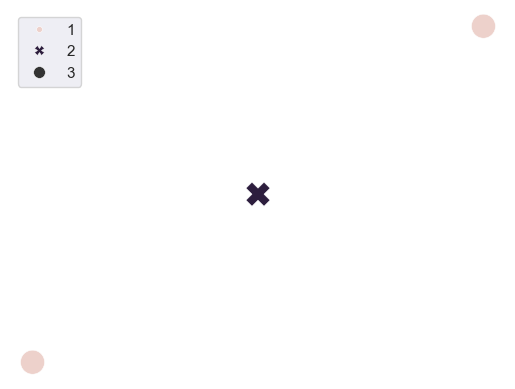

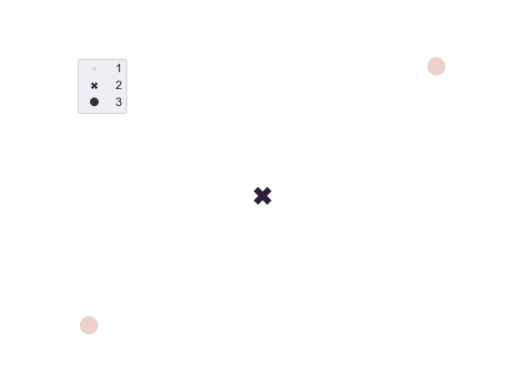

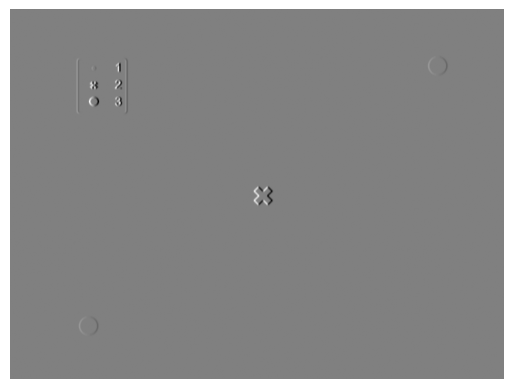

In [13]:
import jax.numpy as jnp
from jax import random
from jax import jit
import jax
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import io
import numpy as np
import seaborn as sns
import keras
key = random.PRNGKey(0)

ax = sns.scatterplot(x=[1,2,3], y=[1,2,3], hue=[1,2,1], size=[1,2,3], style=[1,2,1])
ax.collections[0].set_sizes([300])
plt.axis('off')

plt.savefig('img.png')

img = keras.utils.load_img("img.png")
imarr = keras.utils.img_to_array(img)/255.

#kernel = jnp.array([[1,0,-1], [1,0,-1], [1,0,-1]])
kernel = jnp.array([[1,1,1], [0,0,0], [-1,-1,-1]])
#kernel = jnp.tril(jnp.ones((3,3)))

def kernel_initializer(shape, dtype):
    return np.expand_dims(np.tile(kernel, (3,1,1)), -1)

conv = keras.layers.Conv2D(1, kernel.shape, kernel_initializer=kernel_initializer)
plt.figure()
plt.imshow(imarr)
plt.axis('off')

plt.figure()
img_filt = conv(np.expand_dims(imarr, 0))

plt.imshow(img_filt[0], cmap='gray')
plt.axis('off')

# Zadanie 

Zbudowac model klasyfikacji obrazów

- dodać walidację
- dropout
- narysować przebieg loss z treningu
- Narysować filtry pierwszej warstwy splotowej
- Zobaczyć przykłady błędnej klasyfikacji

In [17]:
import glob
import keras
from sklearn.model_selection import train_test_split
import os

labels = []
imgs = []

for im in glob.glob("./dataset_3labels_small/*/*/*.png"):
    label = im.split(os.path.sep)[-2]
    #print(label, os.path.sep)
    labels.append(label)
    image = keras.utils.load_img(im)
    input_arr = keras.utils.img_to_array(image)

    imgs.append(input_arr)

imgs
  

[array([[[135., 136., 131.],
         [101., 103., 102.],
         [105., 109., 118.],
         ...,
         [207., 202., 183.],
         [201., 198., 179.],
         [197., 194., 175.]],
 
        [[128., 129., 124.],
         [ 75.,  77.,  76.],
         [ 79.,  83.,  92.],
         ...,
         [194., 188., 166.],
         [180., 175., 156.],
         [165., 160., 141.]],
 
        [[124., 125., 120.],
         [ 71.,  73.,  72.],
         [ 85.,  90.,  96.],
         ...,
         [206., 195., 167.],
         [196., 185., 167.],
         [190., 181., 166.]],
 
        ...,
 
        [[ 61.,  60.,  65.],
         [ 56.,  55.,  60.],
         [ 52.,  53.,  58.],
         ...,
         [ 27.,  30.,  35.],
         [ 26.,  29.,  36.],
         [ 24.,  27.,  34.]],
 
        [[ 48.,  47.,  52.],
         [ 53.,  52.,  57.],
         [ 54.,  55.,  60.],
         ...,
         [ 27.,  30.,  35.],
         [ 26.,  30.,  33.],
         [ 24.,  28.,  31.]],
 
        [[ 47.,  46.,  51.],
 

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.stack(imgs) / 255.0 - 0.5
u = list(np.unique(labels))

ilabels = np.asarray([u.index(l) for l in labels])
X_train, X_test, y_train, y_test = train_test_split(X, ilabels, test_size=0.33, shuffle=True, random_state=42)

In [19]:
import keras
from keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D

model = keras.Sequential(
    [
        Conv2D(4, (5,5), strides=(1,1), activation='relu'),
        MaxPooling2D((3,3), strides=(2,2)),
        Conv2D(8, (3,3), strides=(2,2), activation='relu'),
        MaxPooling2D((3,3), strides=(2,2)),
        Conv2D(16, (3,3), strides=(2,2), activation='relu'),
        Flatten(),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(3)
    ]
)

model.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer='adam',metrics=['accuracy'])

h = model.fit(X_train, y_train, batch_size=64, epochs=20, verbose=1, validation_data=(X_test, y_test))


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.4714 - loss: 1.0653 - val_accuracy: 0.5000 - val_loss: 1.0205
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4961 - loss: 1.0047 - val_accuracy: 0.5180 - val_loss: 0.9567
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5276 - loss: 0.9434 - val_accuracy: 0.5720 - val_loss: 0.8861
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5680 - loss: 0.8982 - val_accuracy: 0.6360 - val_loss: 0.8310
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6203 - loss: 0.8387 - val_accuracy: 0.6920 - val_loss: 0.7691
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6824 - loss: 0.7844 - val_accuracy: 0.7160 - val_loss: 0.7048
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7012 - loss: 0.7237 - val_accuracy: 0.7200 - val_loss: 0.6543
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7199 - loss: 0.6626 - val_accuracy: 0.7720 - v

<Axes: >

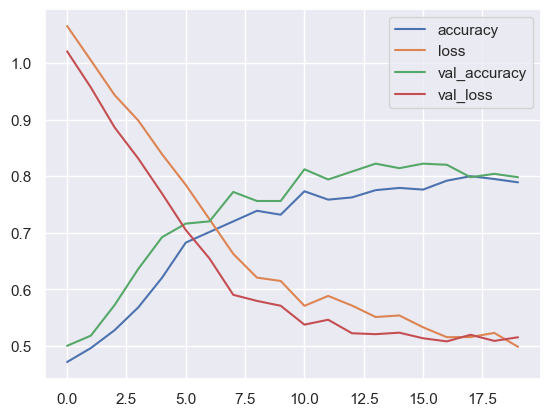

In [20]:
import pandas as pd
pd.DataFrame(h.history).plot()

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 4)      │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,947 (27.14 KB)

 Trainable params: 2,315 (9.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,632 (18.10 KB)

In [22]:
l = Conv2D(4, (3, 3), strides=(2, 2), activation="relu", name='warstwa')
l

bx = X_train[1:5]
bx.shape

l(bx).shape

inp = keras.Input(shape=bx.shape[1:])


o=MaxPooling2D((3,3), strides=(2,2)) (l(inp))#.shape

modelf = keras.Model(inputs=inp, outputs=o)

modelf(bx)

modelf.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ warstwa (Conv2D)                │ (None, 31, 31, 4)      │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 4)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112 (448.00 B)

 Trainable params: 112 (448.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
l.weights[0]

<Variable path=warstwa/kernel, shape=(3, 3, 3, 4), dtype=float32, value=[[[[-0.24329278 -0.17755711 -0.18437958 -0.12686326]
   [-0.29509956  0.13337746  0.28363624 -0.14979777]
   [ 0.02889994  0.00121924  0.25573632 -0.02192155]]

  [[ 0.03480917  0.27951595 -0.02112162  0.30127516]
   [ 0.08191949 -0.03976905  0.13751471  0.26029727]
   [ 0.19959107 -0.12158701 -0.20848058  0.23864165]]

  [[ 0.10870439 -0.24853717  0.09052792 -0.15718679]
   [-0.21908297  0.18757874 -0.07813659  0.14859968]
   [-0.09111427  0.24988124 -0.2341691  -0.28873423]]]


 [[[-0.27861854 -0.2931927   0.2928826   0.2993692 ]
   [-0.253951    0.00086954  0.01552927 -0.12485357]
   [ 0.20430604 -0.23340139  0.13845879  0.04421505]]

  [[-0.12465557 -0.22727045  0.11454543 -0.16418578]
   [-0.0098182  -0.21168047  0.26049963 -0.06864074]
   [-0.27973068 -0.18769565 -0.02122551  0.13979349]]

  [[ 0.09566462  0.0523887   0.18889445 -0.15274926]
   [-0.05104223  0.07506862 -0.22554815  0.00951594]
   [-0.1614832 

In [24]:
model.evaluate(X_test, y_test), model.metrics_names

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7980 - loss: 0.5151


([0.5151306986808777, 0.7979999780654907], ['loss', 'compile_metrics'])

(6, 12)


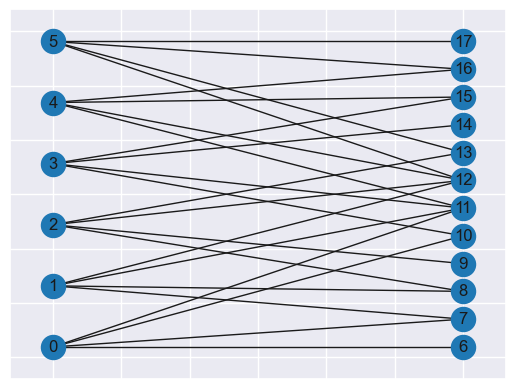

In [26]:
import tensorflow as tf
import numpy as np
import keras
im = np.random.normal(size=(12))
imv = tf.Variable(im)
conv = keras.layers.Conv2D(1,(2,2))


with tf.GradientTape() as tape:
  img = tf.reshape(imv, (1,3,4,1))
  y = conv(img)
  y = tf.experimental.numpy.ravel(y)

W=tape.jacobian(y, imv)

print(W.shape)
import networkx as nx
s,r = np.where(np.abs(W)>1e-5)
s,r
G=nx.Graph()

for a,b in zip(s,r):
    G.add_edge(a,b+6)

pos = nx.bipartite_layout(G, list(range(6)))
nx.draw_networkx(G, pos=pos)

(5, 5, 3, 4)


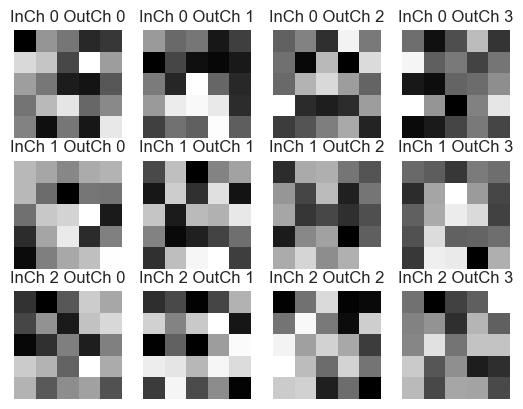

In [27]:
w=model.layers[0].weights[0]

shape = w.shape
print(shape)

fig, axs = plt.subplots(ncols=shape[-1], nrows=shape[-2])

for i in range(shape[-1]):
  for j in range(shape[-2]):
    axs[j,i].imshow(w[:, :, j, i], cmap='gray')
    axs[j,i].axis('off')
    axs[j,i].set_title(f'InCh {j} OutCh {i}')